<a href="https://colab.research.google.com/github/Z4nata/CalculoNumerico/blob/main/Atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade I - Calculo Numerico
### Erros numericos em aplicacoes simples de biofluidodinamica
Nome(s): Felipe Pinto Zanata

## Parte A - truncamento e arredondamento


In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ---- funcoes reaproveitadas no resto do notebook ----

def truncar(x: float, n: int) -> float:
    """Trunca x para n casas decimais sem arredondar."""
    fator = 10 ** n
    return math.trunc(x * fator) / fator


def erro_absoluto(x_ref: float, x_aprox: float) -> float:
    """Ea = |x - x~|"""
    return abs(x_ref - x_aprox)


def erro_relativo(x_ref: float, x_aprox: float) -> float:
    """Er = |x - x~| / |x|"""
    return erro_absoluto(x_ref, x_aprox) / abs(x_ref)


def erro_percentual(x_ref: float, x_aprox: float) -> float:
    """E% = 100 * Er"""
    return 100 * erro_relativo(x_ref, x_aprox)


# ---- dados da Parte A ----

valores_referencia = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765,
}
casas_decimais = [0, 1, 2, 3, 4]

linhas = []
for nome, x_ref in valores_referencia.items():
    for n in casas_decimais:
        x_trunc = truncar(x_ref, n)
        x_round = round(x_ref, n)
        linhas.append({
            "valor": nome, "x_ref": x_ref, "n": n, "metodo": "truncamento",
            "aproximacao": x_trunc,
            "Ea": erro_absoluto(x_ref, x_trunc),
            "Er": erro_relativo(x_ref, x_trunc),
            "E%": erro_percentual(x_ref, x_trunc),
        })
        linhas.append({
            "valor": nome, "x_ref": x_ref, "n": n, "metodo": "arredondamento",
            "aproximacao": x_round,
            "Ea": erro_absoluto(x_ref, x_round),
            "Er": erro_relativo(x_ref, x_round),
            "E%": erro_percentual(x_ref, x_round),
        })

tabela_a = pd.DataFrame(linhas)
pd.set_option("display.float_format", lambda v: f"{v:.10g}")
tabela_a

,valor,x_ref,n,metodo,aproximacao,Ea,Er,E%
0,x1,3.14159265,0,truncamento,3,0.14159265,0.04507034036,4.507034036
1,x1,3.14159265,0,arredondamento,3,0.14159265,0.04507034036,4.507034036
2,x1,3.14159265,1,truncamento,3.1,0.04159265,0.0132393517,1.32393517
3,x1,3.14159265,1,arredondamento,3.1,0.04159265,0.0132393517,1.32393517
4,x1,3.14159265,2,truncamento,3.14,0.00159265,0.0005069562408,0.05069562408
5,x1,3.14159265,2,arredondamento,3.14,0.00159265,0.0005069562408,0.05069562408
6,x1,3.14159265,3,truncamento,3.141,0.00059265,0.0001886463543,0.01886463543
7,x1,3.14159265,3,arredondamento,3.142,0.00040735,0.0001296635323,0.01296635323
8,x1,3.14159265,4,truncamento,3.1415,9.265e-05,2.949141099e-05,0.002949141099
9,x1,3.14159265,4,arredondamento,3.1416,7.35e-06,2.339577666e-06,0.0002339577666


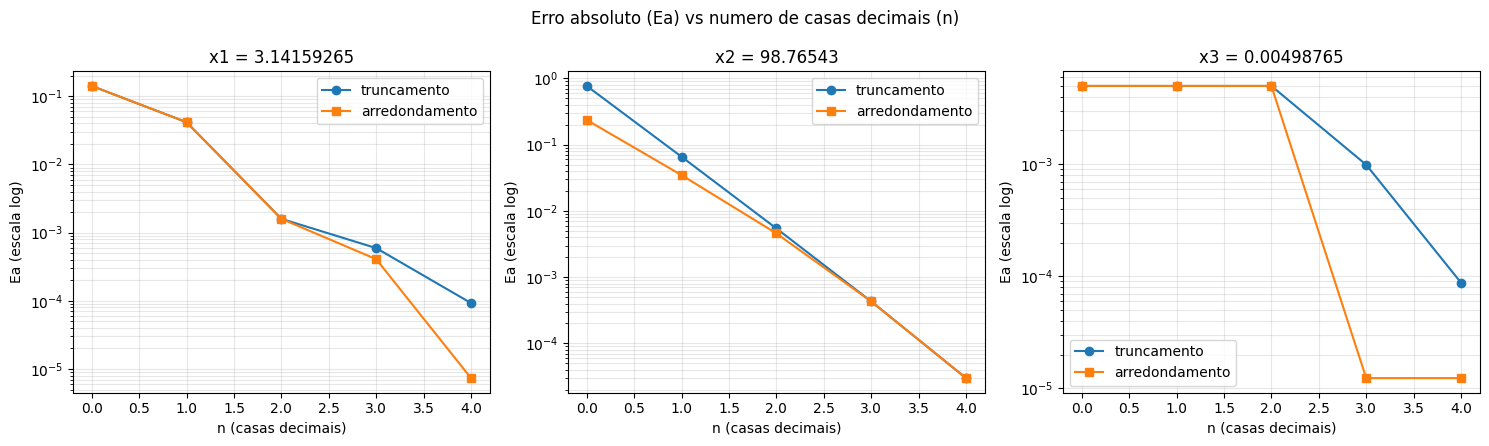

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))

for eixo, (nome, x_ref) in zip(eixos, valores_referencia.items()):
    sub = tabela_a[tabela_a["valor"] == nome]
    for metodo, marcador in [("truncamento", "o"), ("arredondamento", "s")]:
        dados = sub[sub["metodo"] == metodo]
        eixo.semilogy(dados["n"], dados["Ea"], marker=marcador, label=metodo)
    eixo.set_title(f"{nome} = {x_ref}")
    eixo.set_xlabel("n (casas decimais)")
    eixo.set_ylabel("Ea (escala log)")
    eixo.grid(True, which="both", alpha=0.3)
    eixo.legend()

fig.suptitle("Erro absoluto (Ea) vs numero de casas decimais (n)")
fig.tight_layout()
fig.savefig("parte_a_grafico_erro.png", dpi=150)
plt.show()

**Pergunta:** arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.

 Em toda combinação de valor e n na tabela acima, o Ea do arredondamento foi menor ou igual ao do truncamento, nunca maior. E isso já era esperado matematicamente: arredondar escolhe o mais próximo entre "cortar pra baixo" e "cortar pra cima", então o erro máximo dele é 0.5 x 10^-n. Já o truncamento só corta pra baixo, então o erro pode chegar perto de 1 x 10^-n (o dobro, no pior caso). O caso mais claro na tabela é o x3 com n=3: truncar deu E% = 19.8%, arredondar deu E% = 0.25%.

## Parte B - medidas de pressao arterial


In [ ]:
import numpy as np

medidas_originais = np.array([
    121.7, 120.4, 122.1, 119.8, 121.2,
    120.9, 122.4, 121.0, 120.2, 121.5,
])

series = {
    "originais": medidas_originais,
    "arredondadas (inteiro)": np.round(medidas_originais),
    "truncadas (inteiro)": np.trunc(medidas_originais),
    "arredondadas (1 casa)": np.round(medidas_originais, 1),
}

media_referencia = medidas_originais.mean()

resumo_b = []
for nome, dados in series.items():
    media = dados.mean()
    resumo_b.append({
        "serie": nome,
        "media (mmHg)": media,
        "minimo (mmHg)": dados.min(),
        "maximo (mmHg)": dados.max(),
        "amplitude (mmHg)": dados.max() - dados.min(),
        "desvio_padrao_amostral (mmHg)": dados.std(ddof=1),
        "Ea_media (mmHg)": erro_absoluto(media_referencia, media),
        "Er_media": erro_relativo(media_referencia, media),
        "E%_media": erro_percentual(media_referencia, media),
    })

resumo_b = pd.DataFrame(resumo_b)
print(f"Media de referencia: {media_referencia:.4f} mmHg")
resumo_b

Media de referencia: 121.1200 mmHg


,serie,media (mmHg),minimo (mmHg),maximo (mmHg),amplitude (mmHg),desvio_padrao_amostral (mmHg),Ea_media (mmHg),Er_media,E%_media
0,originais,121.12,119.8,122.4,2.6,0.8337332374,0,0,0
1,arredondadas (inteiro),121.1,120,122,2,0.8755950358,0.02,0.0001651254954,0.01651254954
2,truncadas (inteiro),120.7,119,122,3,0.9486832981,0.42,0.003467635403,0.3467635403
3,arredondadas (1 casa),121.12,119.8,122.4,2.6,0.8337332374,0,0,0


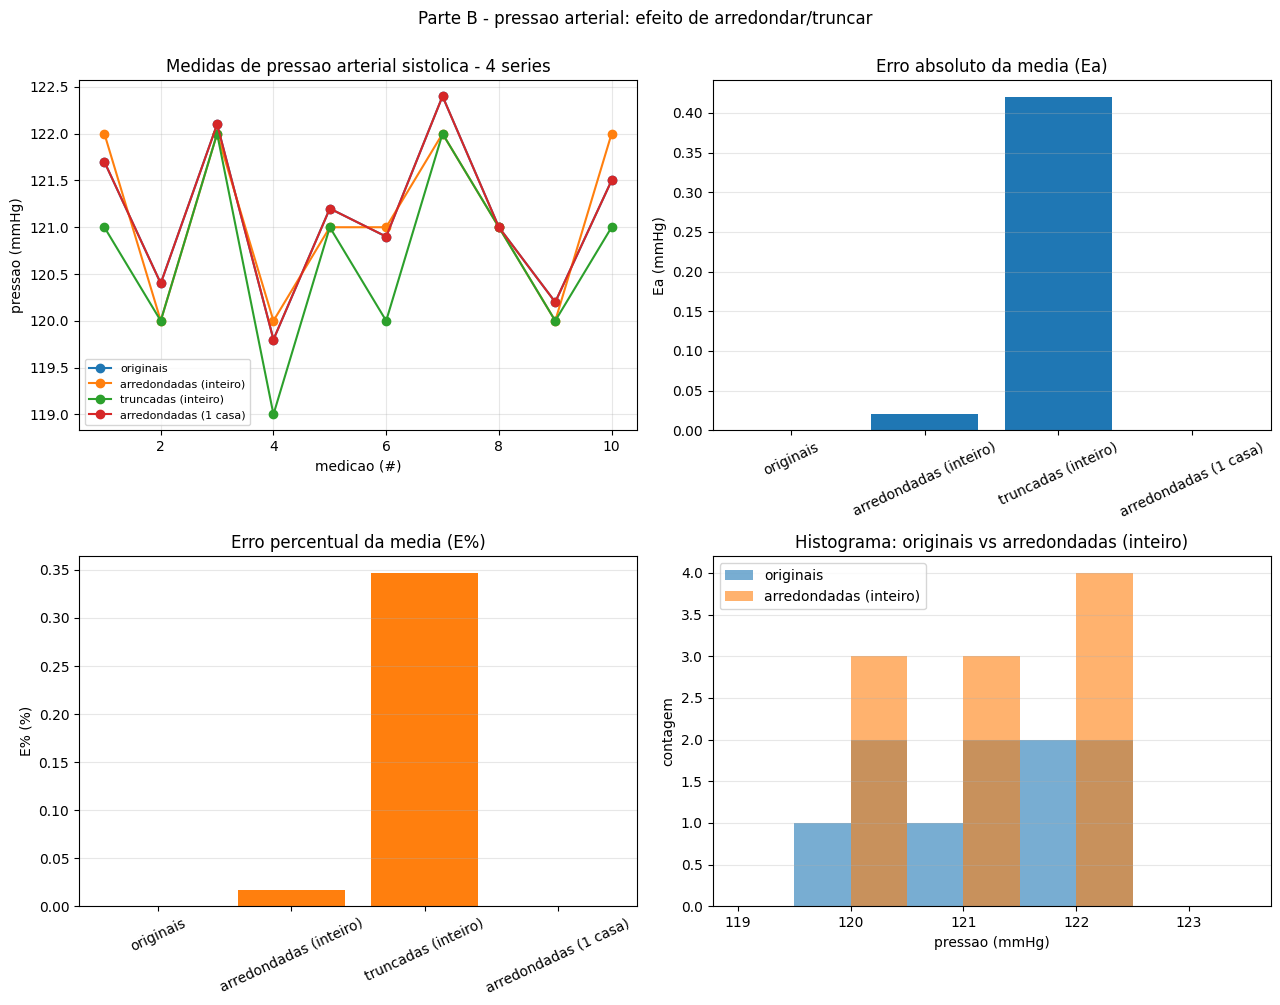

In [ ]:
indice_medicao = np.arange(1, 11)
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

for nome, dados in series.items():
    ax[0, 0].plot(indice_medicao, dados, marker="o", label=nome)
ax[0, 0].set_title("Medidas de pressao arterial sistolica - 4 series")
ax[0, 0].set_xlabel("medicao (#)")
ax[0, 0].set_ylabel("pressao (mmHg)")
ax[0, 0].legend(fontsize=8)
ax[0, 0].grid(alpha=0.3)

ax[0, 1].bar(resumo_b["serie"], resumo_b["Ea_media (mmHg)"], color="tab:blue")
ax[0, 1].set_title("Erro absoluto da media (Ea)")
ax[0, 1].set_ylabel("Ea (mmHg)")
ax[0, 1].tick_params(axis="x", rotation=25)
ax[0, 1].grid(axis="y", alpha=0.3)

ax[1, 0].bar(resumo_b["serie"], resumo_b["E%_media"], color="tab:orange")
ax[1, 0].set_title("Erro percentual da media (E%)")
ax[1, 0].set_ylabel("E% (%)")
ax[1, 0].tick_params(axis="x", rotation=25)
ax[1, 0].grid(axis="y", alpha=0.3)

bins = np.arange(119, 124, 0.5)
ax[1, 1].hist(series["originais"], bins=bins, alpha=0.6, label="originais")
ax[1, 1].hist(series["arredondadas (inteiro)"], bins=bins, alpha=0.6,
              label="arredondadas (inteiro)")
ax[1, 1].set_title("Histograma: originais vs arredondadas (inteiro)")
ax[1, 1].set_xlabel("pressao (mmHg)")
ax[1, 1].set_ylabel("contagem")
ax[1, 1].legend()
ax[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle("Parte B - pressao arterial: efeito de arredondar/truncar", y=1.00)
fig.tight_layout()
fig.savefig("parte_b_graficos.png", dpi=150)
plt.show()

**Discussao:** a representacao inteira e suficiente para preservar a media e a variabilidade desta amostra?

Arredondar para inteiro custa pouco na média, porque os arredondamentos individuais ora sobem ora descem e acabam se cancelando. Truncar para inteiro é bem pior, porque trunca sempre pra baixo, é um viés sistemático, não um erro que se cancela.

Já o desvio-padrão amostral sobe nas duas versões inteiras: quantizar para inteiro injeta ruído artificial na dispersão, e isso pesa proporcionalmente mais numa amostra pequena.

## Parte C - vazao em um tubo de pequeno diametro


In [ ]:
def vazao_hagen_poiseuille(r, L, mu, dp):
    """Q = pi * r^4 * dp / (8 * mu * L), tudo em unidades SI (m, Pa, s)."""
    return math.pi * r**4 * dp / (8 * mu * L)


# ---- dados de referencia (Parte C) ----
r_c = 0.80e-3    # 0.80 mm -> m
L_c = 0.20       # m
mu_c = 3.5e-3    # Pa s
dp_c = 1200      # Pa

Q_ref_c = vazao_hagen_poiseuille(r_c, L_c, mu_c, dp_c)
print(f"Q de referencia (tubo): {Q_ref_c:.6e} m3/s  =  {Q_ref_c*1e6*60:.4f} mL/min")

Q de referencia (tubo): 2.757421e-07 m3/s  =  16.5445 mL/min


### C.1 - Precisao das variaveis


In [ ]:
# r arredondado/truncado para 1 casa decimal em mm (depois convertido p/ m)
r_c_round = round(r_c * 1e3, 1) / 1e3
r_c_trunc = truncar(r_c * 1e3, 1) / 1e3

# mu arredondada/truncada para 3 casas decimais em Pa.s
mu_c_round = round(mu_c, 3)
mu_c_trunc = truncar(mu_c, 3)

# dp arredondado/truncado para centenas de pascal (n=-2 casas decimais)
dp_c_round = round(dp_c, -2)
dp_c_trunc = truncar(dp_c, -2)

cenarios_c = {
    "referencia (tudo exato)":        (r_c,       mu_c,       dp_c),
    "r arredondado (1 casa mm)":      (r_c_round, mu_c,       dp_c),
    "r truncado (1 casa mm)":         (r_c_trunc, mu_c,       dp_c),
    "mu arredondada (3 casas)":       (r_c,       mu_c_round, dp_c),
    "mu truncada (3 casas)":          (r_c,       mu_c_trunc, dp_c),
    "dp arredondado (centena)":       (r_c,       mu_c,       dp_c_round),
    "dp truncado (centena)":          (r_c,       mu_c,       dp_c_trunc),
    "todas arredondadas":             (r_c_round, mu_c_round, dp_c_round),
    "todas truncadas":                (r_c_trunc, mu_c_trunc, dp_c_trunc),
}

linhas_c = []
for nome, (r_i, mu_i, dp_i) in cenarios_c.items():
    Q_i = vazao_hagen_poiseuille(r_i, L_c, mu_i, dp_i)
    linhas_c.append({
        "cenario": nome,
        "r (mm)": r_i * 1e3,
        "mu (Pa.s)": mu_i,
        "dp (Pa)": dp_i,
        "Q (mL/min)": Q_i * 1e6 * 60,
        "Ea (mL/min)": erro_absoluto(Q_ref_c, Q_i) * 1e6 * 60,
        "Er": erro_relativo(Q_ref_c, Q_i),
        "E%": erro_percentual(Q_ref_c, Q_i),
    })

tabela_c1 = pd.DataFrame(linhas_c)
tabela_c1

,cenario,r (mm),mu (Pa.s),dp (Pa),Q (mL/min),Ea (mL/min),Er,E%
0,referencia (tudo exato),0.8,0.0035,1200,16.54452451,0,0,0
1,r arredondado (1 casa mm),0.8,0.0035,1200,16.54452451,0,0,0
2,r truncado (1 casa mm),0.8,0.0035,1200,16.54452451,0,0,0
3,mu arredondada (3 casas),0.8,0.004,1200,14.47645895,2.068065564,0.125,12.5
4,mu truncada (3 casas),0.8,0.003,1200,19.30194526,2.757420752,0.1666666667,16.66666667
5,dp arredondado (centena),0.8,0.0035,1200,16.54452451,0,0,0
6,dp truncado (centena),0.8,0.0035,1200,16.54452451,0,0,0
7,todas arredondadas,0.8,0.004,1200,14.47645895,2.068065564,0.125,12.5
8,todas truncadas,0.8,0.003,1200,19.30194526,2.757420752,0.1666666667,16.66666667


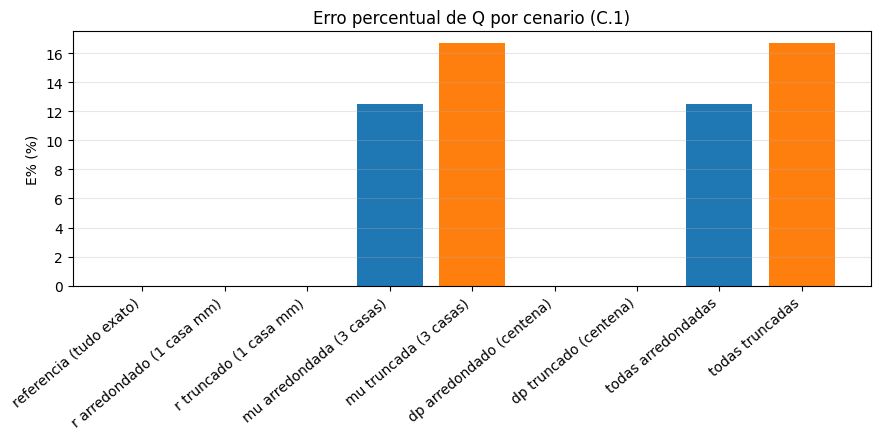

In [ ]:
fig, eixo = plt.subplots(figsize=(9, 4.5))
cores = ["tab:gray" if "referencia" in c else
         ("tab:orange" if "truncad" in c else "tab:blue")
         for c in tabela_c1["cenario"]]
eixo.bar(tabela_c1["cenario"], tabela_c1["E%"], color=cores)
eixo.set_ylabel("E% (%)")
eixo.set_title("Erro percentual de Q por cenario (C.1)")
eixo.tick_params(axis="x", rotation=40)
for tick in eixo.get_xticklabels():
    tick.set_ha("right")
eixo.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("parte_c1_erros.png", dpi=150)
plt.show()

### C.2 - Sensibilidade de Q ao raio


In [ ]:
r_varredura_mm = np.arange(0.70, 0.90 + 1e-9, 0.01)  # mm, passo de 0.01

registros_c2 = []
for r_mm in r_varredura_mm:
    r_m = r_mm * 1e-3
    r_m_round = round(r_mm, 1) * 1e-3
    r_m_trunc = truncar(r_mm, 1) * 1e-3

    Q_ref_i = vazao_hagen_poiseuille(r_m, L_c, mu_c, dp_c)
    Q_round_i = vazao_hagen_poiseuille(r_m_round, L_c, mu_c, dp_c)
    Q_trunc_i = vazao_hagen_poiseuille(r_m_trunc, L_c, mu_c, dp_c)

    registros_c2.append({
        "r (mm)": r_mm,
        "Q_ref (mL/min)": Q_ref_i * 1e6 * 60,
        "Q_round (mL/min)": Q_round_i * 1e6 * 60,
        "Q_trunc (mL/min)": Q_trunc_i * 1e6 * 60,
        "Ea_round": erro_absoluto(Q_ref_i, Q_round_i),
        "Ea_trunc": erro_absoluto(Q_ref_i, Q_trunc_i),
        "Er_round": erro_relativo(Q_ref_i, Q_round_i),
        "Er_trunc": erro_relativo(Q_ref_i, Q_trunc_i),
        "E%_round": erro_percentual(Q_ref_i, Q_round_i),
        "E%_trunc": erro_percentual(Q_ref_i, Q_trunc_i),
    })

tabela_c2 = pd.DataFrame(registros_c2)
tabela_c2.head()

,r (mm),Q_ref (mL/min),Q_round (mL/min),Q_trunc (mL/min),Ea_round,Ea_trunc,Er_round,Er_trunc,E%_round,E%_trunc
0,0.7,9.698096522,9.698096522,9.698096522,0,0,0,0,0,0
1,0.71,10.26426219,9.698096522,9.698096522,9.436094426e-09,9.436094426e-09,0.05515892475,0.05515892475,5.515892475,5.515892475
2,0.72,10.85486253,9.698096522,9.698096522,1.927943351e-08,1.927943351e-08,0.10656662,0.10656662,10.656662,10.656662
3,0.73,11.47059068,9.698096522,9.698096522,2.954156933e-08,2.954156933e-08,0.1545250989,0.1545250989,15.45250989,15.45250989
4,0.74,12.11214945,9.698096522,9.698096522,4.023421555e-08,4.023421555e-08,0.1993083839,0.1993083839,19.93083839,19.93083839


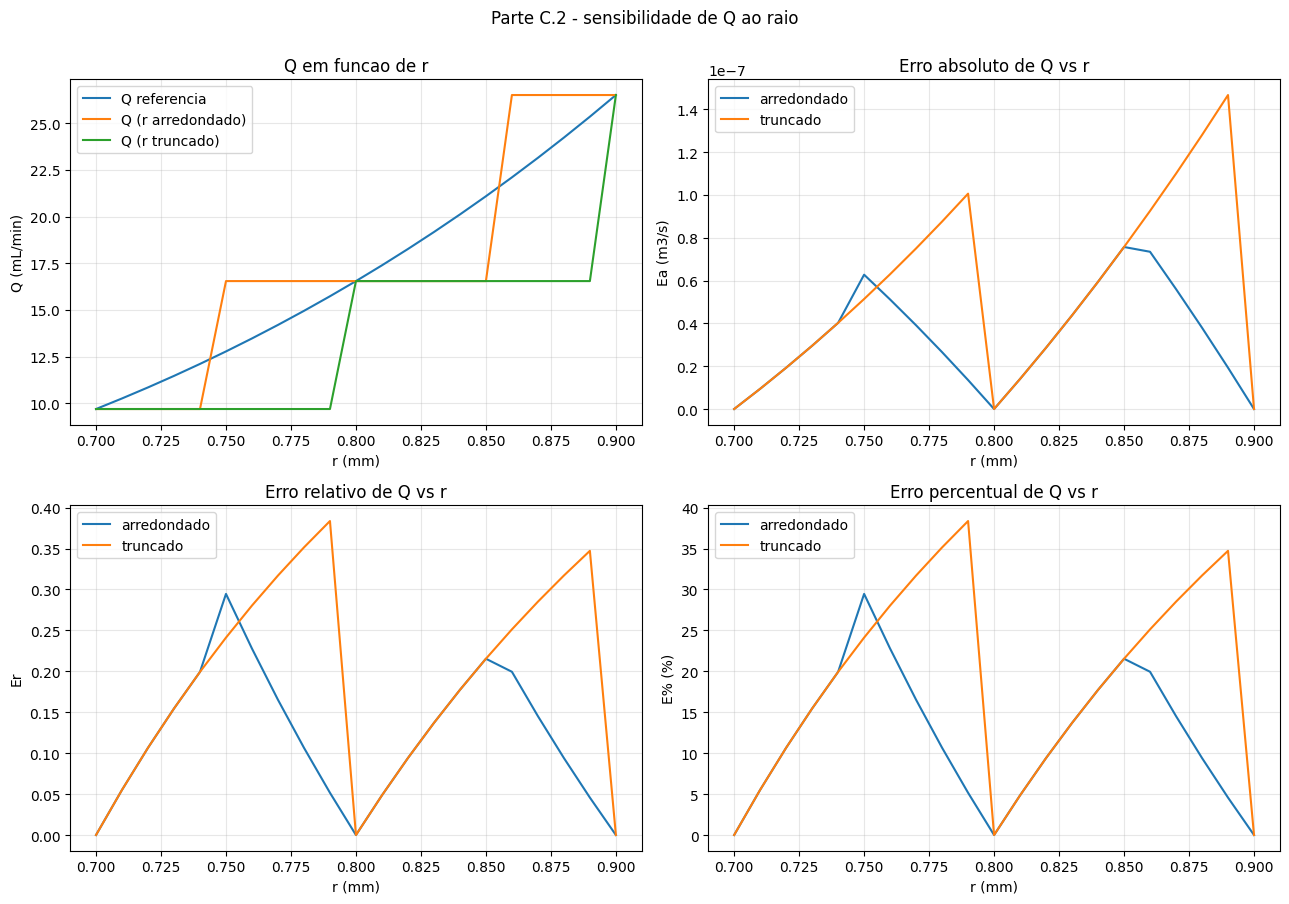

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(tabela_c2["r (mm)"], tabela_c2["Q_ref (mL/min)"], label="Q referencia")
ax[0, 0].plot(tabela_c2["r (mm)"], tabela_c2["Q_round (mL/min)"], label="Q (r arredondado)")
ax[0, 0].plot(tabela_c2["r (mm)"], tabela_c2["Q_trunc (mL/min)"], label="Q (r truncado)")
ax[0, 0].set_title("Q em funcao de r")
ax[0, 0].set_xlabel("r (mm)")
ax[0, 0].set_ylabel("Q (mL/min)")
ax[0, 0].legend()
ax[0, 0].grid(alpha=0.3)

ax[0, 1].plot(tabela_c2["r (mm)"], tabela_c2["Ea_round"], label="arredondado")
ax[0, 1].plot(tabela_c2["r (mm)"], tabela_c2["Ea_trunc"], label="truncado")
ax[0, 1].set_title("Erro absoluto de Q vs r")
ax[0, 1].set_xlabel("r (mm)")
ax[0, 1].set_ylabel("Ea (m3/s)")
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.3)

ax[1, 0].plot(tabela_c2["r (mm)"], tabela_c2["Er_round"], label="arredondado")
ax[1, 0].plot(tabela_c2["r (mm)"], tabela_c2["Er_trunc"], label="truncado")
ax[1, 0].set_title("Erro relativo de Q vs r")
ax[1, 0].set_xlabel("r (mm)")
ax[1, 0].set_ylabel("Er")
ax[1, 0].legend()
ax[1, 0].grid(alpha=0.3)

ax[1, 1].plot(tabela_c2["r (mm)"], tabela_c2["E%_round"], label="arredondado")
ax[1, 1].plot(tabela_c2["r (mm)"], tabela_c2["E%_trunc"], label="truncado")
ax[1, 1].set_title("Erro percentual de Q vs r")
ax[1, 1].set_xlabel("r (mm)")
ax[1, 1].set_ylabel("E% (%)")
ax[1, 1].legend()
ax[1, 1].grid(alpha=0.3)

fig.suptitle("Parte C.2 - sensibilidade de Q ao raio", y=1.00)
fig.tight_layout()
fig.savefig("parte_c2_sensibilidade.png", dpi=150)
plt.show()

**Por que o erro no raio e amplificado na vazao?**

Como Q é proporcional a r^4, uma variação relativa pequena em r acaba elevada à quarta potência. Pela regra da cadeia, dQ/Q ≈ 4 dr/r: um erro relativo de 1% no raio vira uns 4% de erro relativo na vazão. É por isso que os degraus no gráfico de Q x r quando r é arredondado/truncado para 1 casa produzem saltos bem maiores em Q do que a variação de r sozinha sugeriria — o expoente 4 amplifica qualquer imprecisão geométrica. Essa mesma relação dQ/Q ≈ 4 dr/r volta a aparecer na Parte D.

## Parte D - escoamento em um nanocateter


In [ ]:
r_d = 50e-9     # 50 nm -> m
L_d = 10e-6     # 10 um -> m
mu_d = 3.5e-3   # Pa s
dp_d = 5000     # Pa

Q_ref_d = vazao_hagen_poiseuille(r_d, L_d, mu_d, dp_d)
print(f"Q de referencia (nanocateter): {Q_ref_d:.6e} m3/s  =  {Q_ref_d*1e18:.4f} fL/s")

Q de referencia (nanocateter): 3.506242e-19 m3/s  =  0.3506 fL/s


### D.1 - Erro geometrico


In [ ]:
delta_r_nm = np.arange(0.1, 5.0 + 1e-9, 0.1)  # nm

registros_d1 = []
for dr_nm in delta_r_nm:
    dr_m = dr_nm * 1e-9
    r_menos = r_d - dr_m
    r_mais = r_d + dr_m

    Q_menos = vazao_hagen_poiseuille(r_menos, L_d, mu_d, dp_d)
    Q_mais = vazao_hagen_poiseuille(r_mais, L_d, mu_d, dp_d)

    Ea_menos = erro_absoluto(Q_ref_d, Q_menos)
    Ea_mais = erro_absoluto(Q_ref_d, Q_mais)
    # erro maximo = o pior caso entre r- e r+
    Ea_max = max(Ea_menos, Ea_mais)
    Er_max = Ea_max / abs(Q_ref_d)
    Epct_max = 100 * Er_max

    registros_d1.append({
        "dr (nm)": dr_nm,
        "Q(r-) (fL/s)": Q_menos * 1e18,
        "Q(r) (fL/s)": Q_ref_d * 1e18,
        "Q(r+) (fL/s)": Q_mais * 1e18,
        "Ea_max (m3/s)": Ea_max,
        "Er_max": Er_max,
        "E%_max": Epct_max,
        "aprox_linear_E%": 100 * 4 * (dr_m / r_d),  # eq. (5): dQ/Q ~= 4 dr/r
    })

tabela_d1 = pd.DataFrame(registros_d1)
tabela_d1.head()

,dr (nm),Q(r-) (fL/s),Q(r) (fL/s),Q(r+) (fL/s),Ea_max (m3/s),Er_max,E%_max,aprox_linear_E%
0,0.1,0.3478275904,0.3506241801,0.3534375997,2.813419647e-21,0.008024032016,0.8024032016,0.8
1,0.2,0.3450477635,0.3506241801,0.3562679167,5.643736652e-21,0.01609625626,1.609625626,1.6
2,0.3,0.3422846321,0.3506241801,0.3591151986,8.491018539e-21,0.0242168653,2.42168653,2.4
3,0.4,0.3395381294,0.3506241801,0.3619795131,1.135533296e-20,0.0323860521,3.23860521,3.2
4,0.5,0.3368081884,0.3506241801,0.3648609278,1.423674771e-20,0.04060401,4.060401,4


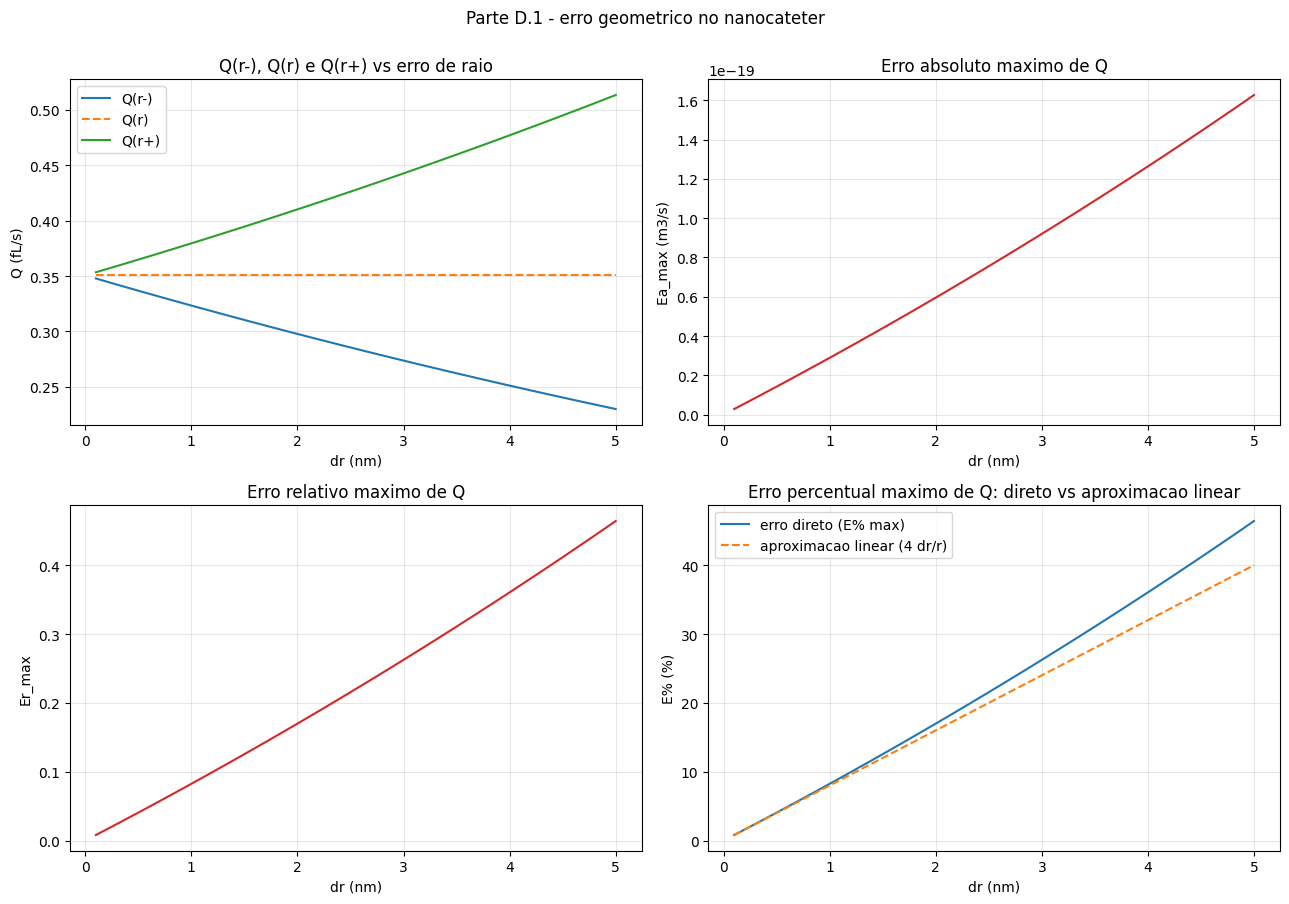

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(tabela_d1["dr (nm)"], tabela_d1["Q(r-) (fL/s)"], label="Q(r-)")
ax[0, 0].plot(tabela_d1["dr (nm)"], tabela_d1["Q(r) (fL/s)"], label="Q(r)", linestyle="--")
ax[0, 0].plot(tabela_d1["dr (nm)"], tabela_d1["Q(r+) (fL/s)"], label="Q(r+)")
ax[0, 0].set_title("Q(r-), Q(r) e Q(r+) vs erro de raio")
ax[0, 0].set_xlabel("dr (nm)")
ax[0, 0].set_ylabel("Q (fL/s)")
ax[0, 0].legend()
ax[0, 0].grid(alpha=0.3)

ax[0, 1].plot(tabela_d1["dr (nm)"], tabela_d1["Ea_max (m3/s)"], color="tab:red")
ax[0, 1].set_title("Erro absoluto maximo de Q")
ax[0, 1].set_xlabel("dr (nm)")
ax[0, 1].set_ylabel("Ea_max (m3/s)")
ax[0, 1].grid(alpha=0.3)

ax[1, 0].plot(tabela_d1["dr (nm)"], tabela_d1["Er_max"], color="tab:red")
ax[1, 0].set_title("Erro relativo maximo de Q")
ax[1, 0].set_xlabel("dr (nm)")
ax[1, 0].set_ylabel("Er_max")
ax[1, 0].grid(alpha=0.3)

ax[1, 1].plot(tabela_d1["dr (nm)"], tabela_d1["E%_max"], label="erro direto (E% max)")
ax[1, 1].plot(tabela_d1["dr (nm)"], tabela_d1["aprox_linear_E%"], "--",
              label="aproximacao linear (4 dr/r)")
ax[1, 1].set_title("Erro percentual maximo de Q: direto vs aproximacao linear")
ax[1, 1].set_xlabel("dr (nm)")
ax[1, 1].set_ylabel("E% (%)")
ax[1, 1].legend()
ax[1, 1].grid(alpha=0.3)

fig.suptitle("Parte D.1 - erro geometrico no nanocateter", y=1.00)
fig.tight_layout()
fig.savefig("parte_d1_erro_geometrico.png", dpi=150)
plt.show()

### D.2 - Precisao computacional (float32 vs float64)


In [ ]:
for tipo in (np.float32, np.float64):
    r_t = tipo(r_d)
    L_t = tipo(L_d)
    mu_t = tipo(mu_d)
    dp_t = tipo(dp_d)

    r4_t = r_t**4
    Q_t = tipo(math.pi) * r4_t * dp_t / (tipo(8) * mu_t * L_t)

    print(f"{tipo.__name__}: r^4 = {r4_t!r}, Q = {Q_t!r} m3/s, eps = {np.finfo(tipo).eps!r}")

Q_f32 = np.float32(math.pi) * np.float32(r_d)**4 * np.float32(dp_d) / (np.float32(8) * np.float32(mu_d) * np.float32(L_d))
Q_f64 = np.float64(math.pi) * np.float64(r_d)**4 * np.float64(dp_d) / (np.float64(8) * np.float64(mu_d) * np.float64(L_d))

dif_abs = abs(float(Q_f64) - float(Q_f32))
dif_rel = dif_abs / abs(float(Q_f64))
print(f"\ndiferenca absoluta Q64-Q32: {dif_abs:.6e} m3/s")
print(f"diferenca relativa: {dif_rel:.6e}  ({dif_rel*100:.6f} %)")

float32: r^4 = np.float32(6.2500004e-30), Q = np.float32(3.5062423e-19) m3/s, eps = np.float32(1.1920929e-07)
float64: r^4 = np.float64(6.249999999999999e-30), Q = np.float64(3.506241800881465e-19) m3/s, eps = np.float64(2.220446049250313e-16)

diferenca absoluta Q64-Q32: 5.228628e-26 m3/s
diferenca relativa: 1.491234e-07  (0.000015 %)


In [ ]:
razoes_dr_r = np.logspace(-1, -12, 50)  # dr/r de 0.1 ate 1e-12

registros_d2 = []
for razao in razoes_dr_r:
    linha = {"dr/r": razao, "aprox_linear (4x)": 4 * razao}
    for tipo in (np.float32, np.float64):
        r_t = tipo(r_d)
        L_t = tipo(L_d)
        mu_t = tipo(mu_d)
        dp_t = tipo(dp_d)
        dr_t = tipo(razao) * r_t

        Q_r = tipo(math.pi) * r_t**4 * dp_t / (tipo(8) * mu_t * L_t)
        Q_r_dr = tipo(math.pi) * (r_t + dr_t)**4 * dp_t / (tipo(8) * mu_t * L_t)

        delta1 = (Q_r_dr - Q_r) / Q_r
        delta2 = (tipo(1) + tipo(razao))**4 - tipo(1)

        linha[f"delta1_{tipo.__name__}"] = float(delta1)
        linha[f"delta2_{tipo.__name__}"] = float(delta2)
    registros_d2.append(linha)

tabela_d2 = pd.DataFrame(registros_d2)
tabela_d2.iloc[::7]  # mostra so algumas linhas (a cada 7) pra nao poluir

,dr/r,aprox_linear (4x),delta1_float32,delta2_float32,delta1_float64,delta2_float64
0,0.1,0.4,0.4641000628,0.4641001225,0.4641,0.4641
7,0.002682695795,0.01073078318,0.01077416167,0.01077401638,0.0107740416,0.0107740416
14,7.19685673e-05,0.0002878742692,0.0002878919186,0.0002880096436,0.0002879053475,0.0002879053475
21,1.930697729e-06,7.722790916e-06,7.593564078e-06,7.629394531e-06,7.722813281e-06,7.722813281e-06
28,5.179474679e-08,2.071789872e-07,2.211717742e-07,0,2.071790032e-07,2.071790028e-07
35,1.389495494e-09,5.557981977e-09,0,0,5.557981787e-09,5.55798163e-09
42,3.72759372e-11,1.491037488e-10,0,0,1.491035792e-10,1.491038404e-10
49,1e-12,4e-12,0,0,4.000038826e-12,4.000355602e-12


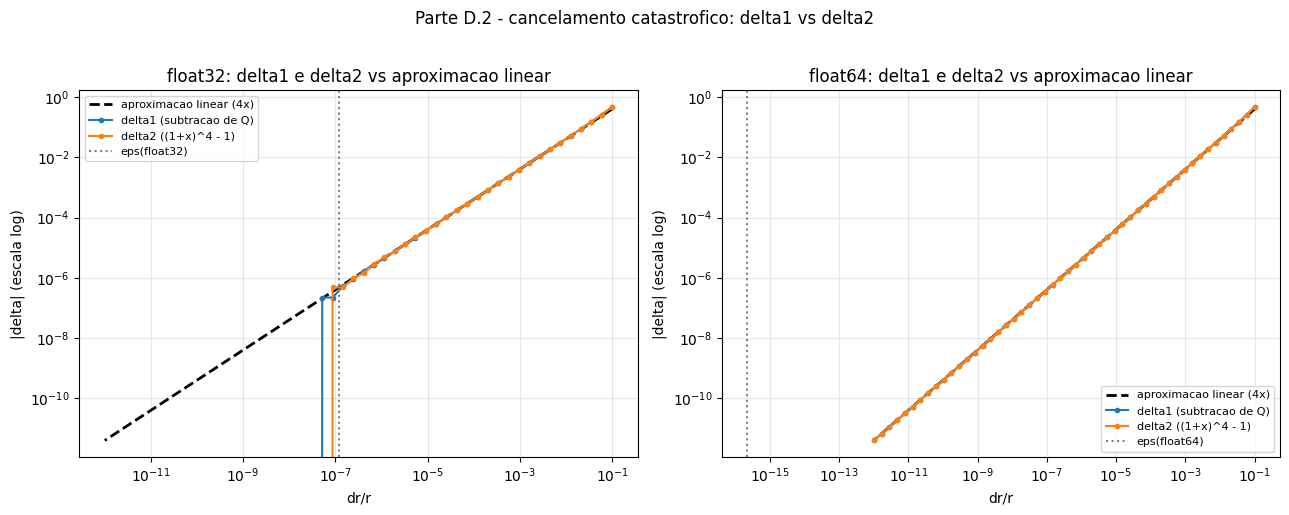

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for eixo, tipo_nome in zip(ax, ["float32", "float64"]):
    eixo.loglog(tabela_d2["dr/r"], tabela_d2["aprox_linear (4x)"], "k--",
                label="aproximacao linear (4x)", linewidth=2)
    eixo.loglog(tabela_d2["dr/r"], tabela_d2[f"delta1_{tipo_nome}"].abs(),
                marker=".", label="delta1 (subtracao de Q)")
    eixo.loglog(tabela_d2["dr/r"], tabela_d2[f"delta2_{tipo_nome}"].abs(),
                marker=".", label="delta2 ((1+x)^4 - 1)")
    eps = np.finfo(getattr(np, tipo_nome)).eps
    eixo.axvline(eps, color="gray", linestyle=":", label=f"eps({tipo_nome})")
    eixo.set_title(f"{tipo_nome}: delta1 e delta2 vs aproximacao linear")
    eixo.set_xlabel("dr/r")
    eixo.set_ylabel("|delta| (escala log)")
    eixo.legend(fontsize=8)
    eixo.grid(True, which="both", alpha=0.3)

fig.suptitle("Parte D.2 - cancelamento catastrofico: delta1 vs delta2", y=1.02)
fig.tight_layout()
fig.savefig("parte_d2_cancelamento.png", dpi=150)
plt.show()

### D.3 - Fenomeno fisico
Ao reduzir a escala do raio de milímetros (tubo, Parte C) para nanômetros (nanocateter, Parte D), a razão entre área de superfície e volume do canal aumenta muito — a superfície encolhe com r e o volume com r^2 (numa seção transversal), então superfície/volume escala como 1/r. Isso significa que efeitos de parede (atrito viscoso do fluido com a parede do canal) passam a dominar sobre efeitos de volume, algo que a fórmula de Hagen-Poiseuille — deduzida para um contínuo, sem considerar interações moleculares na parede — não captura em escala nanométrica.

Um resultado numericamente preciso (poucos erros de arredondamento, boa precisão em float64) pode ainda assim ser fisicamente inadequado: precisão aritmética (quantos dígitos corretos o computador entrega) e validade do modelo (se a fórmula ainda descreve o fenômeno real naquela escala) são coisas diferentes.

## Parte E - sintese visual


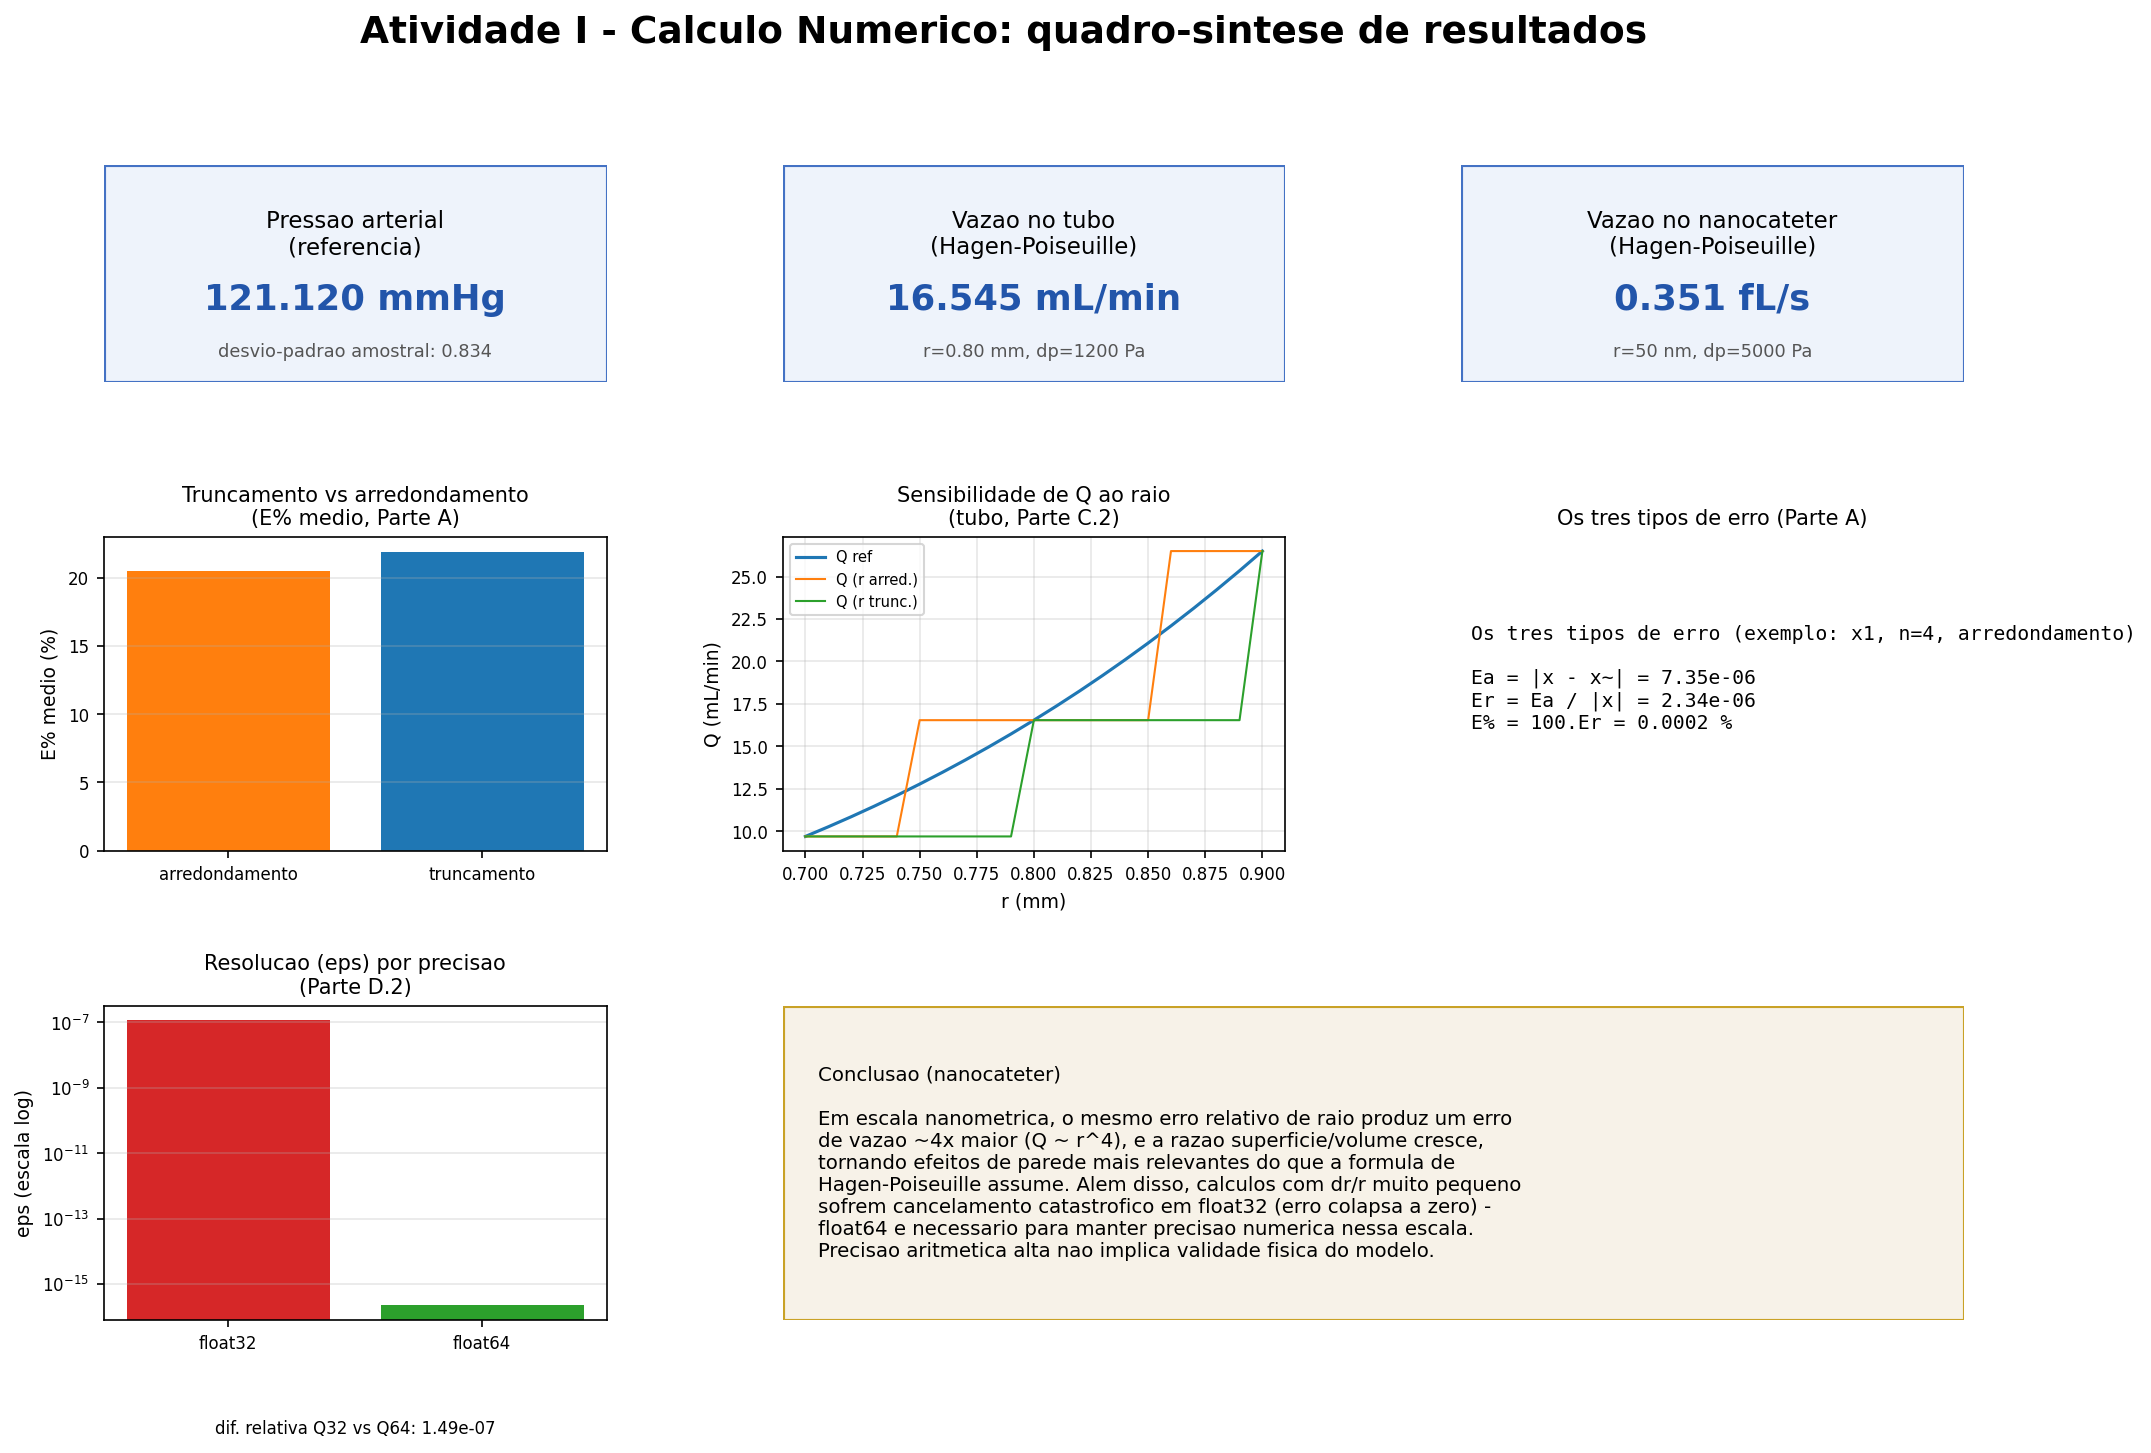

Tamanho final do PNG: 2151 x 1453 px


In [ ]:
fig = plt.figure(figsize=(16, 10), dpi=150)  # 16*150=2400 x 10*150=1500 px
gs = fig.add_gridspec(3, 3, height_ratios=[0.9, 1.3, 1.3], hspace=0.55, wspace=0.35)

fig.suptitle("Atividade I - Calculo Numerico: quadro-sintese de resultados",
             fontsize=18, fontweight="bold", y=0.98)

# ---------- linha 1: cartoes com os principais valores ----------
cartoes = [
    ("Pressao arterial\n(referencia)", f"{media_referencia:.3f} mmHg",
     f"desvio-padrao amostral: {resumo_b.loc[resumo_b.serie=='originais','desvio_padrao_amostral (mmHg)'].values[0]:.3f}"),
    ("Vazao no tubo\n(Hagen-Poiseuille)", f"{Q_ref_c*1e6*60:.3f} mL/min",
     f"r=0.80 mm, dp=1200 Pa"),
    ("Vazao no nanocateter\n(Hagen-Poiseuille)", f"{Q_ref_d*1e18:.3f} fL/s",
     f"r=50 nm, dp=5000 Pa"),
]
for col, (titulo, valor, nota) in enumerate(cartoes):
    ax = fig.add_subplot(gs[0, col])
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                facecolor="#eef3fb", edgecolor="#4472c4", linewidth=1.5))
    ax.text(0.5, 0.68, titulo, ha="center", va="center", fontsize=11, transform=ax.transAxes)
    ax.text(0.5, 0.38, valor, ha="center", va="center", fontsize=17, fontweight="bold",
            color="#2255aa", transform=ax.transAxes)
    ax.text(0.5, 0.14, nota, ha="center", va="center", fontsize=8.5, color="#555555",
            transform=ax.transAxes)

# ---------- linha 2, coluna 0: truncamento vs arredondamento ----------
ax = fig.add_subplot(gs[1, 0])
media_por_metodo = tabela_a.groupby("metodo")["E%"].mean()
ax.bar(media_por_metodo.index, media_por_metodo.values,
       color=["tab:orange", "tab:blue"])
ax.set_title("Truncamento vs arredondamento\n(E% medio, Parte A)", fontsize=10)
ax.set_ylabel("E% medio (%)", fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(axis="y", alpha=0.3)

# ---------- linha 2, coluna 1: sensibilidade de Q ao raio (tubo) ----------
ax = fig.add_subplot(gs[1, 1])
ax.plot(tabela_c2["r (mm)"], tabela_c2["Q_ref (mL/min)"], label="Q ref", linewidth=1.5)
ax.plot(tabela_c2["r (mm)"], tabela_c2["Q_round (mL/min)"], label="Q (r arred.)", linewidth=1)
ax.plot(tabela_c2["r (mm)"], tabela_c2["Q_trunc (mL/min)"], label="Q (r trunc.)", linewidth=1)
ax.set_title("Sensibilidade de Q ao raio\n(tubo, Parte C.2)", fontsize=10)
ax.set_xlabel("r (mm)", fontsize=9)
ax.set_ylabel("Q (mL/min)", fontsize=9)
ax.legend(fontsize=7)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.3)

# ---------- linha 2, coluna 2: os tres tipos de erro (texto) ----------
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
exemplo = tabela_a[(tabela_a.valor == "x1") & (tabela_a.n == 4) & (tabela_a.metodo == "arredondamento")].iloc[0]
texto_erros = (
    "Os tres tipos de erro (exemplo: x1, n=4, arredondamento)\n\n"
    f"Ea = |x - x~| = {exemplo['Ea']:.2e}\n"
    f"Er = Ea / |x| = {exemplo['Er']:.2e}\n"
    f"E% = 100.Er = {exemplo['E%']:.4f} %"
)
ax.text(0.02, 0.55, texto_erros, ha="left", va="center", fontsize=9.5,
        transform=ax.transAxes, family="monospace")
ax.set_title("Os tres tipos de erro (Parte A)", fontsize=10)

# ---------- linha 3, coluna 0: float32 vs float64 ----------
ax = fig.add_subplot(gs[2, 0])
ax.bar(["float32", "float64"], [np.finfo(np.float32).eps, np.finfo(np.float64).eps],
       color=["tab:red", "tab:green"])
ax.set_yscale("log")
ax.set_title("Resolucao (eps) por precisao\n(Parte D.2)", fontsize=10)
ax.set_ylabel("eps (escala log)", fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(axis="y", which="both", alpha=0.3)
ax.text(0.5, -0.32, f"dif. relativa Q32 vs Q64: {dif_rel:.2e}",
        ha="center", va="top", fontsize=8, transform=ax.transAxes)

# ---------- linha 3, colunas 1-2: conclusao ----------
ax = fig.add_subplot(gs[2, 1:])
ax.axis("off")
conclusao = (
    "Conclusao (nanocateter)\n\n"
    "Em escala nanometrica, o mesmo erro relativo de raio produz um erro\n"
    "de vazao ~4x maior (Q ~ r^4), e a razao superficie/volume cresce,\n"
    "tornando efeitos de parede mais relevantes do que a formula de\n"
    "Hagen-Poiseuille assume. Alem disso, calculos com dr/r muito pequeno\n"
    "sofrem cancelamento catastrofico em float32 (erro colapsa a zero) -\n"
    "float64 e necessario para manter precisao numerica nessa escala.\n"
    "Precisao aritmetica alta nao implica validade fisica do modelo."
)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                            facecolor="#f7f2e8", edgecolor="#c9a227", linewidth=1.5))
ax.text(0.03, 0.5, conclusao, ha="left", va="center", fontsize=9.5, transform=ax.transAxes)

fig.savefig("parte_e_quadro_sintese.png", dpi=150, bbox_inches="tight")
plt.show()

import PIL.Image
img = PIL.Image.open("parte_e_quadro_sintese.png")
print(f"Tamanho final do PNG: {img.size[0]} x {img.size[1]} px")

## 8. GIF demonstrativo


In [ ]:
import io
import PIL.Image

n_subida = 20
raios_gif_nm = np.concatenate([
    np.linspace(45, 55, n_subida),
    np.linspace(55, 45, n_subida),
])

Q0_gif = vazao_hagen_poiseuille(r_d, L_d, mu_d, dp_d) * 1e18  # fL/s, referencia r=50nm
Q_gif_todas = np.array([
    vazao_hagen_poiseuille(r_nm * 1e-9, L_d, mu_d, dp_d) * 1e18
    for r_nm in raios_gif_nm
])
y_min_gif, y_max_gif = Q_gif_todas.min() * 0.9, Q_gif_todas.max() * 1.1

frames_gif = []
for i, r_nm in enumerate(raios_gif_nm):
    Q_atual = Q_gif_todas[i]
    erro_pct = 100 * (Q_atual - Q0_gif) / Q0_gif

    fig, (ax_corte, ax_curva) = plt.subplots(1, 2, figsize=(10, 4.5), dpi=100)

    circulo = plt.Circle((0, 0), r_nm, color="#4472c4", alpha=0.5)
    ax_corte.add_patch(circulo)
    circulo_ref = plt.Circle((0, 0), 50, fill=False, color="black",
                              linestyle="--", linewidth=1)
    ax_corte.add_patch(circulo_ref)
    lim = 61
    ax_corte.set_xlim(-lim, lim)
    ax_corte.set_ylim(-lim, lim)
    ax_corte.set_aspect("equal")
    ax_corte.set_title("Secao transversal do nanocateter")
    ax_corte.set_xlabel("nm")
    ax_corte.text(0.5, -0.18,
                  f"r = {r_nm:.2f} nm\nQ = {Q_atual:.4f} fL/s\nerro vs r=50nm: {erro_pct:+.2f}%",
                  ha="center", va="top", transform=ax_corte.transAxes, fontsize=10)

    ax_curva.plot(raios_gif_nm[:i+1], Q_gif_todas[:i+1], color="tab:blue", linewidth=1.5)
    ax_curva.scatter([r_nm], [Q_atual], color="tab:red", zorder=5)
    ax_curva.set_xlim(44, 56)
    ax_curva.set_ylim(y_min_gif, y_max_gif)
    ax_curva.set_xlabel("r (nm)")
    ax_curva.set_ylabel("Q (fL/s)")
    ax_curva.set_title("Q x r (construcao progressiva)")
    ax_curva.grid(alpha=0.3)

    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)
    frames_gif.append(PIL.Image.open(buf).convert("RGB"))

frames_gif[0].save("nanocateter.gif", save_all=True, append_images=frames_gif[1:],
                    duration=90, loop=0)
print(f"GIF salvo com {len(frames_gif)} quadros: nanocateter.gif")

GIF salvo com 40 quadros: nanocateter.gif


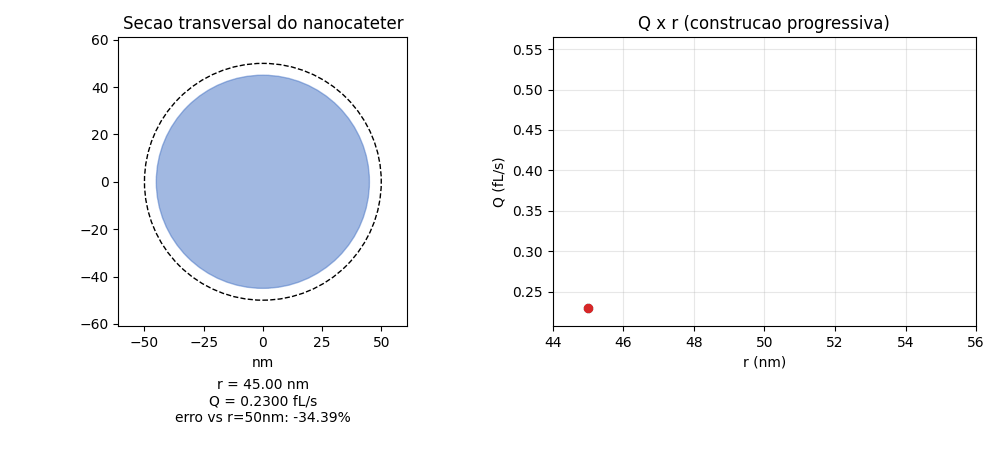

In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="nanocateter.gif"))

## Conclusao geral
Ao longo desta atividade, o mesmo par de operações — truncar e arredondar — apareceu em contextos bem diferentes (um número isolado, a média de uma amostra, uma variável dentro de uma fórmula física), e em todos eles arredondar se mostrou consistentemente mais seguro que truncar, porque truncar introduz um viés sistemático (sempre na mesma direção), enquanto arredondar produz erros que tendem a se cancelar. As Partes C e D mostraram que o efeito de um erro de entrada sobre o resultado depende de como a fórmula usa essa entrada — como Q é proporcional a r^4, um pequeno erro no raio é amplificado por um fator de aproximadamente 4x na vazão, e esse efeito fica ainda mais crítico em escala nanométrica, onde a razão superfície/volume torna o próprio modelo físico menos confiável. Por fim, a Parte D.2 mostrou que a escolha do tipo de ponto flutuante (float32 vs float64) também é uma fonte de erro numérico — não físico, mas computacional — que pode dominar o resultado quando as grandezas envolvidas são muito pequenas ou muito próximas entre si (cancelamento catastrófico). A lição geral é que precisão numérica (quantos dígitos corretos o computador entrega) e validade física (se o modelo ainda descreve o fenômeno) são perguntas independentes, e as duas precisam ser verificadas.